# 牙齿全景 X 光片实例分割实验

实验对象为全景 X 光片，目标是在每张图像中分割 32 个 FDI 牙位对应的牙齿区域，并比较传统图像处理方法与深度学习方法的表现。

本实验包含三类方法：

1. **Active Contour**：无需训练的传统分割基线，用于提供参考下界。
2. **U-Net**：仅输入 X 光图像的监督式分割模型。
3. **OralBBNet**：在 U-Net 基础上加入 YOLO 边界框先验，用空间提示辅助牙齿实例分割。

实验流程包括数据索引、预处理、训练/验证/测试划分、模型训练、最佳权重保存、定量评估和可视化对比。


## 运行环境

建议在支持 TensorFlow GPU 的 Jupyter 环境中运行。若机器上有多张空闲 GPU，本 notebook 会使用 `MirroredStrategy` 进行数据并行训练。主要依赖如下：

```bash
pip install numpy pandas matplotlib pillow tifffile scikit-image scikit-learn opencv-python tensorflow
```

本实验直接使用数据集中已有的 YOLO `.txt` 标签构建 OralBBNet 的边界框先验，因此不需要额外训练或加载 YOLO 检测模型。


In [1]:
import os
# 在 notebook 内显式指定 GPU
GPU_IDS = "1,2,3,4"
if GPU_IDS is not None:
    os.environ["CUDA_VISIBLE_DEVICES"] = GPU_IDS
print("CUDA_VISIBLE_DEVICES=", os.environ.get("CUDA_VISIBLE_DEVICES", "not set; using all visible GPUs"))

# Python 标准库
import random
import re
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

# 图像读取、处理与可视化
from IPython.display import display
from PIL import Image
import cv2
import pandas as pd
import tifffile as tiff

# 深度学习与评估工具
import keras
import numpy as np
import tensorflow as tf
from keras import layers
from matplotlib import pyplot as plt
from skimage import exposure, filters, measure, morphology, segmentation
from sklearn.model_selection import train_test_split

# 基础路径在下一节统一配置
ROOT = Path.cwd()
DATA_ROOT = ROOT / "Dataset" / "bb_u_net_dataset"
YOLO_ROOT = ROOT / "Dataset" / "yolo_train_dataset"
YOLO_TEST_ROOT = ROOT / "Dataset" / "yolo_test_dataset"


CUDA_VISIBLE_DEVICES= 1,2,3,4


I0000 00:00:1778762493.352039  551626 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 实验配置

本次实验使用UFBA-425 数据集进行训练、验证和测试。
预处理结果会缓存到 `cache/`，重复运行时可减少图像和 mask 的读取时间。模型最佳权重和评估结果保存到 `results/`。


In [2]:
NOTEBOOK_ROOT = Path.cwd()
# 支持从项目根目录或 Instance_seg_teeth 子目录运行 notebook
if (NOTEBOOK_ROOT / "Dataset").exists():
    DATA_ROOT = NOTEBOOK_ROOT / "Dataset"
elif (NOTEBOOK_ROOT / "Instance_seg_teeth" / "Dataset").exists():
    DATA_ROOT = NOTEBOOK_ROOT / "Instance_seg_teeth" / "Dataset"
else:
    DATA_ROOT = NOTEBOOK_ROOT / "Dataset"

BB_UNET_ROOT = DATA_ROOT / "bb_u_net_dataset"
YOLO_ROOT = DATA_ROOT / "yolo_train_dataset"
YOLO_TEST_ROOT = DATA_ROOT / "yolo_test_dataset"
RESULTS_DIR = NOTEBOOK_ROOT / "results"
CACHE_DIR = NOTEBOOK_ROOT / "cache"
CHECKPOINT_DIR = RESULTS_DIR / "checkpoints"

# ---------- 模型与训练参数 ----------
IMAGE_SIZE = (512, 512)        # 统一输入尺寸 (H, W)
EPOCHS = 30                    # 完整实验训练轮数
PER_REPLICA_BATCH_SIZE = 1     # 每张 GPU 的 batch size；四卡时 global batch=4
BASE_FILTERS = 64              # 原始 U-Net 宽度；若显存不足再改为 32
LEARNING_RATE = 3e-5           # 多卡 + 小 batch 下使用较保守学习率，降低 NaN 风险
PRED_THRESHOLD = 0.5           # 初始阈值；最终阈值由验证集自动搜索
SEED = 42                  # 固定随机种子，保证划分和训练过程可复现

# 训练/验证/测试划分比例
VALID_SIZE = 0.15
TEST_SIZE = 0.15

# FDI 牙位编号到模型输出通道的映射
OUTPUT_CHANNELS = 32
TOOTH_ORDER = [11, 12, 13, 14, 15, 16, 17, 18,
               21, 22, 23, 24, 25, 26, 27, 28,
               31, 32, 33, 34, 35, 36, 37, 38,
               41, 42, 43, 44, 45, 46, 47, 48]
TOOTH_TO_CHANNEL = {tooth: idx for idx, tooth in enumerate(TOOTH_ORDER)}

# 按牙齿类型分组，便于在结果中分析不同区域的表现
TOOTH_GROUPS = {
    "incisors":  [0, 1, 8, 9, 16, 17, 24, 25],
    "canines":   [2, 10, 18, 26],
    "premolars": [3, 4, 11, 12, 19, 20, 27, 28],
    "molars":    [5, 6, 7, 13, 14, 15, 21, 22, 23, 29, 30, 31],
}

# 缓存和输出目录
CACHE_DIR.mkdir(parents=True, exist_ok=True)
CACHE_VERSION = "v1"
CACHE_SCOPE = f"img{IMAGE_SIZE[0]}x{IMAGE_SIZE[1]}"
PREPROCESS_CACHE_PATH = CACHE_DIR / f"preprocessed_{CACHE_VERSION}_{CACHE_SCOPE}.npz"
CACHE_PREPROCESSED_DATA = True
ENABLE_GPU_MEMORY_GROWTH = True

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# 固定随机性来源
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Data root:", DATA_ROOT)
print("Data root exists:", DATA_ROOT.exists())
print("Preprocess cache:", PREPROCESS_CACHE_PATH)


TensorFlow: 2.21.0
Data root: /oral_llm/xiweidai/dentalagent2/Instance_seg_teeth/Dataset
Data root exists: True
Preprocess cache: /oral_llm/xiweidai/dentalagent2/Instance_seg_teeth/cache/preprocessed_v1_img512x512.npz


In [3]:
enable_gpu_memory_growth = globals().get("ENABLE_GPU_MEMORY_GROWTH", True)

# 按需分配 GPU 显存，避免 TensorFlow 启动时占满显存。
gpus = tf.config.list_physical_devices("GPU")
if enable_gpu_memory_growth:
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError as error:
            print(f"Could not set memory growth for {gpu}: {error}")
else:
    print("GPU memory growth is disabled")

print("Visible GPUs:", gpus)

# 多张可见 GPU 时自动启用 MirroredStrategy；单卡或 CPU 时退回默认策略。
if len(gpus) > 1:
    strategy = tf.distribute.MirroredStrategy()
else:
    strategy = tf.distribute.get_strategy()

NUM_REPLICAS = strategy.num_replicas_in_sync
GLOBAL_BATCH_SIZE = PER_REPLICA_BATCH_SIZE * NUM_REPLICAS
print("Using strategy:", type(strategy).__name__)
print("Replicas:", NUM_REPLICAS, "Global batch size:", GLOBAL_BATCH_SIZE)


Visible GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:2', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:3', device_type='GPU')]
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1', '/job:localhost/replica:0/task:0/device:GPU:2', '/job:localhost/replica:0/task:0/device:GPU:3')
Using strategy: MirroredStrategy
Replicas: 4 Global batch size: 4


I0000 00:00:1778762496.828997  551626 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22362 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:25:00.0, compute capability: 8.6
I0000 00:00:1778762496.832184  551626 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 22362 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:41:00.0, compute capability: 8.6
I0000 00:00:1778762496.836043  551626 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 22362 MB memory:  -> device: 2, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:61:00.0, compute capability: 8.6
I0000 00:00:1778762496.838924  551626 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 22362 MB memory:  -> device: 3, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:81:00.0, compute capability: 8.6


## 数据索引与预处理

UFBA-425 数据集中，每张全景 X 光片对应一个 `.jpg` 文件和多个 `.ome.tiff` 单牙掩码文件。掩码文件名中的 FDI 牙位编号会被映射到 32 个输出通道，因此每个样本的标签形状为 `(H, W, 32)`。

图像统一转换为灰度图，并使用 CLAHE 增强对比度；mask 使用最近邻插值缩放，避免标签边界被插值成非二值。


In [4]:
@dataclass(frozen=True)
class Sample:
    """单个病例样本的图像路径与牙位 mask 路径。"""
    image_id: str
    image_path: Path
    mask_paths: Dict[int, Path]


def normalize_id_from_image(path: Path) -> str:
    """从图像文件名提取病例 ID。"""
    return path.stem


def normalize_id_from_yolo_file(path: Path) -> str:
    """
    从 Roboflow 格式的 YOLO 标签文件名提取病例 ID。
    文件名格式如: cate4-00100_jpg.rf.<hash>.txt
    """
    name = path.stem
    if "_jpg.rf." in name:
        return name.split("_jpg.rf.")[0]
    if ".rf." in name:
        return name.split(".rf.")[0]
    return name


def parse_tooth_number(mask_path: Path) -> Optional[int]:
    """
    从 mask 文件名解析 FDI 牙位编号。
    文件名格式如: <image_id>_11.ome.tiff
    """
    stem = mask_path.stem.replace(".ome", "")
    if "background" in stem.lower():
        return None
    match = re.search(r"_(\d{2})$", stem)
    if not match:
        return None
    tooth_number = int(match.group(1))
    return tooth_number if tooth_number in TOOTH_TO_CHANNEL else None


def build_sample_index(bb_unet_root: Path = BB_UNET_ROOT) -> List[Sample]:
    """将 X 光片与对应的单牙 mask 文件配对。"""
    image_dir = bb_unet_root / "panoramic_x_rays"
    label_root = bb_unet_root / "labels"

    image_paths = sorted(image_dir.glob("*.jpg"))
    if not image_paths:
        raise FileNotFoundError(f"No .jpg images found in {image_dir}")

    # image_id -> {tooth_number -> mask_path}
    mask_index: Dict[str, Dict[int, Path]] = {}
    for mask_path in sorted(label_root.rglob("*.ome.tiff")):
        tooth_number = parse_tooth_number(mask_path)
        if tooth_number is None:
            continue
        image_id = re.sub(r"_\d{2}$", "", mask_path.stem.replace(".ome", ""))
        mask_index.setdefault(image_id, {})[tooth_number] = mask_path

    # 只保留至少包含一个牙位 mask 的样本
    samples = []
    for image_path in image_paths:
        image_id = normalize_id_from_image(image_path)
        mask_paths = mask_index.get(image_id, {})
        if mask_paths:
            samples.append(Sample(image_id=image_id, image_path=image_path, mask_paths=mask_paths))

    if not samples:
        raise RuntimeError("No image/mask pairs were found. Check the dataset paths and mask filenames.")

    return samples


def apply_clahe(image: np.ndarray, clip_limit: float = 0.02) -> np.ndarray:
    """使用 CLAHE 增强 X 光片局部对比度。"""
    image_float = image.astype(np.float32)
    if image_float.max() > 1.0:
        image_float /= 255.0
    image_clahe = exposure.equalize_adapthist(image_float, clip_limit=clip_limit)
    return image_clahe.astype(np.float32)


def resize_image(array: np.ndarray, image_size: Tuple[int, int] = IMAGE_SIZE) -> np.ndarray:
    """缩放 X 光图像。"""
    width, height = image_size[1], image_size[0]
    return cv2.resize(array, (width, height), interpolation=cv2.INTER_AREA)


def resize_mask(array: np.ndarray, image_size: Tuple[int, int] = IMAGE_SIZE) -> np.ndarray:
    """缩放 mask，使用最近邻插值保持二值标签。"""
    width, height = image_size[1], image_size[0]
    return cv2.resize(array, (width, height), interpolation=cv2.INTER_NEAREST)

def load_image_and_mask(sample: Sample, image_size: Tuple[int, int] = IMAGE_SIZE) -> Tuple[np.ndarray, np.ndarray]:
    """
    读取一个样本，并生成 32 通道实例分割标签。
    返回:
        image: (H, W, 1) float32, 经过 CLAHE 增强
        mask:  (H, W, 32) float32, 每个通道对应一个牙齿编号的二值掩码
    """
    image = np.asarray(Image.open(sample.image_path).convert("L"), dtype=np.float32)
    image = resize_image(image, image_size)
    image = apply_clahe(image)
    image = image[..., np.newaxis]

    mask = np.zeros((*image_size, OUTPUT_CHANNELS), dtype=np.float32)
    for tooth_number, mask_path in sample.mask_paths.items():
        channel = TOOTH_TO_CHANNEL[tooth_number]
        tooth_mask = tiff.imread(mask_path)
        if tooth_mask.ndim > 2:
            tooth_mask = np.squeeze(tooth_mask)
        tooth_mask = resize_mask((tooth_mask > 0).astype(np.uint8), image_size)
        mask[..., channel] = (tooth_mask > 0).astype(np.float32)

    return image.astype(np.float32), mask.astype(np.float32)


def mask_union(mask: np.ndarray) -> np.ndarray:
    """计算标签 mask 的二值并集（用于 0/1 真值掩码）。"""
    if mask.ndim == 3:
        return (mask.max(axis=-1) > 0).astype(np.float32)
    return (mask > 0).astype(np.float32)


def prediction_union(pred: np.ndarray) -> np.ndarray:
    """计算预测概率的并集热图，保留 0-1 概率而不是提前二值化。"""
    if pred.ndim == 3:
        return np.max(pred, axis=-1).astype(np.float32)
    return pred.astype(np.float32)


def binarize_prediction(pred: np.ndarray, threshold: float = PRED_THRESHOLD) -> np.ndarray:
    """将预测概率二值化；多通道输入会先取通道最大概率。"""
    return (prediction_union(pred) >= threshold).astype(np.float32)


# 构建完整样本索引
samples = build_sample_index()
print(f"Indexed {len(samples)} samples")
if samples:
    print(samples[0])


Indexed 425 samples
Sample(image_id='cate1-00002', image_path=PosixPath('/oral_llm/xiweidai/dentalagent2/Instance_seg_teeth/Dataset/bb_u_net_dataset/panoramic_x_rays/cate1-00002.jpg'), mask_paths={11: PosixPath('/oral_llm/xiweidai/dentalagent2/Instance_seg_teeth/Dataset/bb_u_net_dataset/labels/cate1 - export/cate1-00002_11.ome.tiff'), 12: PosixPath('/oral_llm/xiweidai/dentalagent2/Instance_seg_teeth/Dataset/bb_u_net_dataset/labels/cate1 - export/cate1-00002_12.ome.tiff'), 13: PosixPath('/oral_llm/xiweidai/dentalagent2/Instance_seg_teeth/Dataset/bb_u_net_dataset/labels/cate1 - export/cate1-00002_13.ome.tiff'), 14: PosixPath('/oral_llm/xiweidai/dentalagent2/Instance_seg_teeth/Dataset/bb_u_net_dataset/labels/cate1 - export/cate1-00002_14.ome.tiff'), 15: PosixPath('/oral_llm/xiweidai/dentalagent2/Instance_seg_teeth/Dataset/bb_u_net_dataset/labels/cate1 - export/cate1-00002_15.ome.tiff'), 16: PosixPath('/oral_llm/xiweidai/dentalagent2/Instance_seg_teeth/Dataset/bb_u_net_dataset/labels/cate1

## 数据集划分与边界框先验

三种方法使用相同的训练集、验证集和测试集，以保证比较公平。OralBBNet 额外需要 32 通道边界框先验：优先从 YOLO 标签文件生成，如果某个样本没有对应标签，则由真实 mask 的最小外接矩形生成先验。


In [5]:
def build_yolo_label_index(roots: Sequence[Path] = (YOLO_ROOT, YOLO_TEST_ROOT)) -> Dict[str, Path]:
    """
    扫描 YOLO 标签目录，建立 image_id -> 标签文件路径的索引。
    注意：同一图像可能有多个 Roboflow 增强版本，只保留第一个。
    """
    label_index: Dict[str, Path] = {}
    for root in roots:
        if not root.exists():
            continue
        for path in sorted(root.rglob("labels/*.txt")):
            image_id = normalize_id_from_yolo_file(path)
            label_index.setdefault(image_id, path)
    return label_index


YOLO_LABEL_INDEX = build_yolo_label_index()
print(f"Indexed {len(YOLO_LABEL_INDEX)} YOLO label files")


def build_yolo_box_prior(
    image_id: str,
    image_size: Tuple[int, int] = IMAGE_SIZE,
    label_index: Dict[str, Path] = YOLO_LABEL_INDEX,
) -> np.ndarray:
    """
    从 YOLO 标签文件构建边界框先验。
    将 YOLO 格式 (class, x_center, y_center, width, height) 的归一化坐标
    转换为 (H, W, 32) 的二值图像，每个通道对应一个牙齿类别的矩形区域。
    """
    prior = np.zeros((*image_size, OUTPUT_CHANNELS), dtype=np.float32)
    label_path = label_index.get(image_id)
    if label_path is None:
        return prior

    height, width = image_size
    with label_path.open("r", encoding="utf-8") as file:
        for line in file:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls, x_center, y_center, box_width, box_height = map(float, parts[:5])
            channel = int(cls)
            if channel < 0 or channel >= OUTPUT_CHANNELS:
                continue

            # 将归一化坐标转换为像素坐标
            x_center *= width
            y_center *= height
            box_width *= width
            box_height *= height
            x1 = max(0, int(round(x_center - box_width / 2)))
            y1 = max(0, int(round(y_center - box_height / 2)))
            x2 = min(width, int(round(x_center + box_width / 2)))
            y2 = min(height, int(round(y_center + box_height / 2)))
            if x2 > x1 and y2 > y1:
                prior[y1:y2, x1:x2, channel] = 1.0

    return prior


def fallback_box_prior_from_mask(mask: np.ndarray) -> np.ndarray:
    """
    退避方案：当没有 YOLO 标签时，从真实掩码计算边界框。
    对每个通道的非零区域取最小外接矩形。
    """
    prior = np.zeros_like(mask, dtype=np.float32)
    for channel in range(mask.shape[-1]):
        coords = np.argwhere(mask[..., channel] > 0)
        if coords.size == 0:
            continue
        y1, x1 = coords.min(axis=0)
        y2, x2 = coords.max(axis=0) + 1
        prior[y1:y2, x1:x2, channel] = 1.0
    return prior

Indexed 426 YOLO label files


In [6]:
def save_preprocessed_cache(
    cache_path: Path,
    train_x: np.ndarray,
    train_y: np.ndarray,
    train_prior: np.ndarray,
    train_ids: Sequence[str],
    train_fallback: int,
    valid_x: np.ndarray,
    valid_y: np.ndarray,
    valid_prior: np.ndarray,
    valid_ids: Sequence[str],
    valid_fallback: int,
    test_x: np.ndarray,
    test_y: np.ndarray,
    test_prior: np.ndarray,
    test_ids: Sequence[str],
    test_fallback: int,
) -> None:
    np.savez(
        cache_path,
        train_x=train_x.astype(np.float16),
        train_y=train_y.astype(np.uint8),
        train_prior=train_prior.astype(np.uint8),
        train_ids=np.asarray(train_ids),
        train_fallback=np.asarray(train_fallback, dtype=np.int32),
        valid_x=valid_x.astype(np.float16),
        valid_y=valid_y.astype(np.uint8),
        valid_prior=valid_prior.astype(np.uint8),
        valid_ids=np.asarray(valid_ids),
        valid_fallback=np.asarray(valid_fallback, dtype=np.int32),
        test_x=test_x.astype(np.float16),
        test_y=test_y.astype(np.uint8),
        test_prior=test_prior.astype(np.uint8),
        test_ids=np.asarray(test_ids),
        test_fallback=np.asarray(test_fallback, dtype=np.int32),
    )


def load_preprocessed_cache(cache_path: Path) -> Dict[str, np.ndarray | int]:
    with np.load(cache_path, allow_pickle=False) as data:
        return {
            "train_x": data["train_x"].astype(np.float32),
            "train_y": data["train_y"].astype(np.float32),
            "train_prior": data["train_prior"].astype(np.float32),
            "train_ids": data["train_ids"].tolist(),
            "train_fallback": int(data["train_fallback"].item()),
            "valid_x": data["valid_x"].astype(np.float32),
            "valid_y": data["valid_y"].astype(np.float32),
            "valid_prior": data["valid_prior"].astype(np.float32),
            "valid_ids": data["valid_ids"].tolist(),
            "valid_fallback": int(data["valid_fallback"].item()),
            "test_x": data["test_x"].astype(np.float32),
            "test_y": data["test_y"].astype(np.float32),
            "test_prior": data["test_prior"].astype(np.float32),
            "test_ids": data["test_ids"].tolist(),
            "test_fallback": int(data["test_fallback"].item()),
        }


def build_or_load_preprocessed_splits():
    """读取完整样本并划分训练、验证和测试集；如缓存存在则直接加载。"""
    if CACHE_PREPROCESSED_DATA and PREPROCESS_CACHE_PATH.exists():
        print(f"Loading cached preprocessed arrays from {PREPROCESS_CACHE_PATH}")
        cached = load_preprocessed_cache(PREPROCESS_CACHE_PATH)
        return (
            cached["train_x"],
            cached["train_y"],
            cached["train_prior"],
            cached["train_ids"],
            cached["train_fallback"],
            cached["valid_x"],
            cached["valid_y"],
            cached["valid_prior"],
            cached["valid_ids"],
            cached["valid_fallback"],
            cached["test_x"],
            cached["test_y"],
            cached["test_prior"],
            cached["test_ids"],
            cached["test_fallback"],
        )

    def load_arrays(samples: Sequence[Sample]) -> Tuple[np.ndarray, np.ndarray, np.ndarray, List[str], int]:
        sample_images, sample_masks, sample_priors, sample_ids = [], [], [], []
        sample_fallback = 0

        for sample in samples:
            image, mask = load_image_and_mask(sample)
            prior = build_yolo_box_prior(sample.image_id)
            # 部分样本可能没有 YOLO 标签，此时由真实 mask 生成矩形先验。
            if prior.max() == 0:
                prior = fallback_box_prior_from_mask(mask)
                sample_fallback += 1

            sample_images.append(image)
            sample_masks.append(mask)
            sample_priors.append(prior)
            sample_ids.append(sample.image_id)

        return (
            np.asarray(sample_images, dtype=np.float32),
            np.asarray(sample_masks, dtype=np.float32),
            np.asarray(sample_priors, dtype=np.float32),
            sample_ids,
            sample_fallback,
        )

    train_samples, temp_samples = train_test_split(samples, test_size=VALID_SIZE + TEST_SIZE, random_state=SEED)
    valid_fraction_of_temp = VALID_SIZE / (VALID_SIZE + TEST_SIZE)
    valid_samples, test_samples = train_test_split(temp_samples, test_size=1 - valid_fraction_of_temp, random_state=SEED)

    train_x, train_y, train_prior, train_ids, train_fallback = load_arrays(train_samples)
    valid_x, valid_y, valid_prior, valid_ids, valid_fallback = load_arrays(valid_samples)
    test_x, test_y, test_prior, test_ids, test_fallback = load_arrays(test_samples)

    if CACHE_PREPROCESSED_DATA:
        save_preprocessed_cache(
            PREPROCESS_CACHE_PATH,
            train_x,
            train_y,
            train_prior,
            train_ids,
            train_fallback,
            valid_x,
            valid_y,
            valid_prior,
            valid_ids,
            valid_fallback,
            test_x,
            test_y,
            test_prior,
            test_ids,
            test_fallback,
        )
        print(f"Saved preprocessed cache to {PREPROCESS_CACHE_PATH}")

    return (
        train_x,
        train_y,
        train_prior,
        train_ids,
        train_fallback,
        valid_x,
        valid_y,
        valid_prior,
        valid_ids,
        valid_fallback,
        test_x,
        test_y,
        test_prior,
        test_ids,
        test_fallback,
    )


(
    train_x,
    train_y,
    train_prior,
    train_ids,
    train_fallback,
    valid_x,
    valid_y,
    valid_prior,
    valid_ids,
    valid_fallback,
    test_x,
    test_y,
    test_prior,
    test_ids,
    test_fallback,
) = build_or_load_preprocessed_splits()



def sanitize_split_arrays(x: np.ndarray, y: np.ndarray, prior: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """清理 NaN/Inf 并限制到合法范围，避免训练初期 loss 变成 NaN。"""
    x = np.nan_to_num(x.astype(np.float32), nan=0.0, posinf=1.0, neginf=0.0)
    y = np.nan_to_num(y.astype(np.float32), nan=0.0, posinf=1.0, neginf=0.0)
    prior = np.nan_to_num(prior.astype(np.float32), nan=0.0, posinf=1.0, neginf=0.0)
    x = np.clip(x, 0.0, 1.0)
    y = (y > 0).astype(np.float32)
    prior = (prior > 0).astype(np.float32)
    return x, y, prior

train_x, train_y, train_prior = sanitize_split_arrays(train_x, train_y, train_prior)
valid_x, valid_y, valid_prior = sanitize_split_arrays(valid_x, valid_y, valid_prior)
test_x, test_y, test_prior = sanitize_split_arrays(test_x, test_y, test_prior)

print("Train:", train_x.shape, train_y.shape, train_prior.shape)
print("Valid:", valid_x.shape, valid_y.shape, valid_prior.shape)
print("Test:", test_x.shape, test_y.shape, test_prior.shape)
print("YOLO prior fallback count:", train_fallback + valid_fallback + test_fallback)

def print_split_sanity(name: str, x: np.ndarray, y: np.ndarray, prior: np.ndarray) -> None:
    mask_pixels = y.sum(axis=(1, 2, 3))
    print(
        f"{name}: x range={x.min():.3f}-{x.max():.3f}, "
        f"mask_positive_ratio={y.mean():.6f}, prior_positive_ratio={prior.mean():.6f}, "
        f"empty_masks={int((mask_pixels == 0).sum())}, "
        f"mask_pixels min/mean/max={mask_pixels.min():.0f}/{mask_pixels.mean():.0f}/{mask_pixels.max():.0f}"
    )

print_split_sanity("Train", train_x, train_y, train_prior)
print_split_sanity("Valid", valid_x, valid_y, valid_prior)
print_split_sanity("Test", test_x, test_y, test_prior)

oral_train_x = np.concatenate([train_prior, train_x], axis=-1)
oral_valid_x = np.concatenate([valid_prior, valid_x], axis=-1)
oral_test_x = np.concatenate([test_prior, test_x], axis=-1)

print("OralBBNet input shape:", oral_train_x.shape)


Loading cached preprocessed arrays from /oral_llm/xiweidai/dentalagent2/Instance_seg_teeth/cache/preprocessed_v1_img512x512.npz
Train: (297, 512, 512, 1) (297, 512, 512, 32) (297, 512, 512, 32)
Valid: (64, 512, 512, 1) (64, 512, 512, 32) (64, 512, 512, 32)
Test: (64, 512, 512, 1) (64, 512, 512, 32) (64, 512, 512, 32)
YOLO prior fallback count: 1
Train: x range=0.000-1.000, mask_positive_ratio=0.005613, prior_positive_ratio=0.008976, empty_masks=0, mask_pixels min/mean/max=2037/47088/79131
Valid: x range=0.000-1.000, mask_positive_ratio=0.005643, prior_positive_ratio=0.009331, empty_masks=0, mask_pixels min/mean/max=8157/47340/71960
Test: x range=0.000-1.000, mask_positive_ratio=0.005915, prior_positive_ratio=0.009539, empty_masks=0, mask_pixels min/mean/max=2401/49617/73281
OralBBNet input shape: (297, 512, 512, 33)


## 样本检查

在训练前展示一个样本的 X 光图像、真实牙齿区域并集和 OralBBNet 使用的边界框先验，用于确认图像、标签和先验在空间上基本对齐。


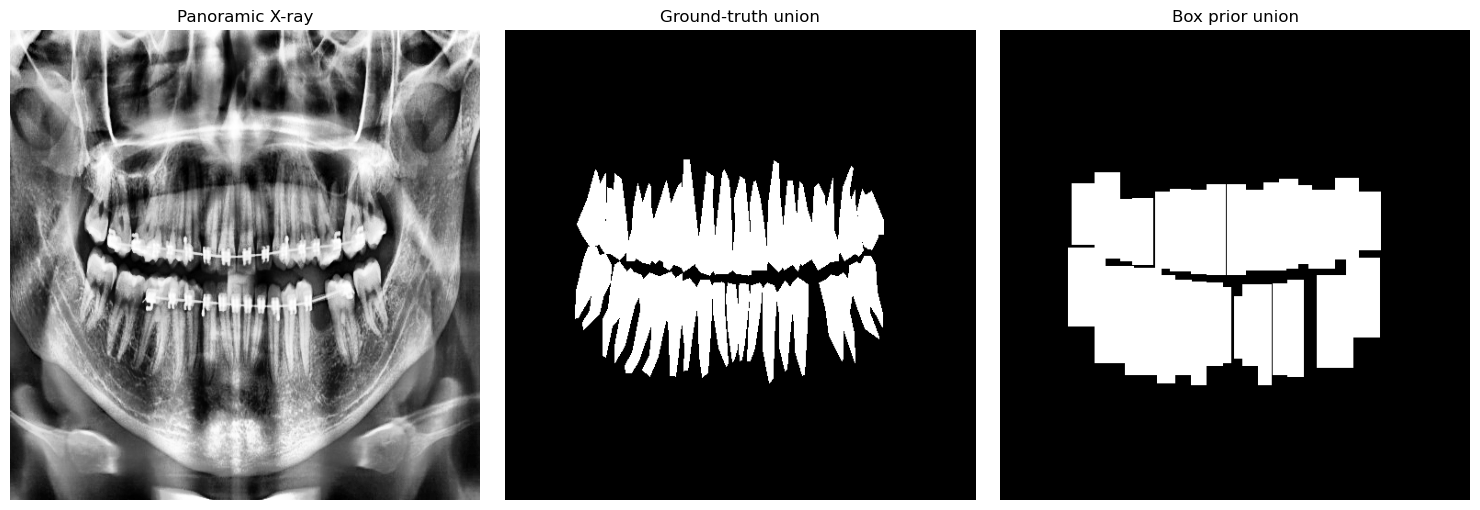

In [7]:
def show_sample(index: int = 0) -> None:
    """展示训练样本的图像、真实分割区域和空间先验。"""
    image = train_x[index]
    mask = train_y[index]
    prior = train_prior[index]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(image.squeeze(), cmap="gray")
    axes[0].set_title("Panoramic X-ray")
    axes[1].imshow(mask_union(mask), cmap="gray")
    axes[1].set_title("Ground-truth union")
    axes[2].imshow(mask_union(prior), cmap="gray")
    axes[2].set_title("Box prior union")
    for axis in axes:
        axis.axis("off")
    plt.tight_layout()


show_sample(0)


## 评估指标

实验采用 Dice 和 IoU 衡量二值分割质量。对于 U-Net 和 OralBBNet，额外计算 32 个牙位通道的平均 Dice，并按门牙、尖牙、前磨牙和磨牙分组统计表现。

模型输出为概率图，因此验证集会用于搜索合适的二值化阈值，再将该阈值应用到测试集评估中。


In [8]:
def evaluate_binary(y_true: np.ndarray, y_pred: np.ndarray, threshold: float = PRED_THRESHOLD, epsilon: float = 1e-7) -> Dict[str, float]:
    """计算二值分割的 Dice 和 IoU。y_pred 可以是概率图或多通道概率。"""
    true_bin = mask_union(y_true) > 0
    pred_bin = prediction_union(y_pred) >= threshold

    intersection = np.logical_and(true_bin, pred_bin).sum(dtype=np.float64)
    true_sum = true_bin.sum(dtype=np.float64)
    pred_sum = pred_bin.sum(dtype=np.float64)
    union = np.logical_or(true_bin, pred_bin).sum(dtype=np.float64)

    return {
        "binary_dice": float((2 * intersection + epsilon) / (true_sum + pred_sum + epsilon)),
        "binary_iou": float((intersection + epsilon) / (union + epsilon)),
        "pred_positive_ratio": float(pred_bin.mean()),
    }


def channel_dice(y_true: np.ndarray, y_pred: np.ndarray, threshold: float = PRED_THRESHOLD, epsilon: float = 1e-7) -> np.ndarray:
    """计算每个通道的 Dice 系数，返回长度为通道数的数组。"""
    true_bin = y_true > 0
    pred_bin = y_pred >= threshold
    intersection = np.logical_and(true_bin, pred_bin).sum(axis=(0, 1), dtype=np.float64)
    true_sum = true_bin.sum(axis=(0, 1), dtype=np.float64)
    pred_sum = pred_bin.sum(axis=(0, 1), dtype=np.float64)
    dice = (2 * intersection + epsilon) / (true_sum + pred_sum + epsilon)
    missing = (true_sum + pred_sum) == 0
    dice[missing] = np.nan
    return dice


def evaluate_multichannel(y_true: np.ndarray, y_pred: np.ndarray, threshold: float = PRED_THRESHOLD) -> Dict[str, float]:
    """计算多通道和牙位分组的平均 Dice。"""
    dices = np.asarray([channel_dice(t, p, threshold=threshold) for t, p in zip(y_true, y_pred)])
    metrics = {"mean_channel_dice": float(np.nanmean(dices))}
    for group_name, indices in TOOTH_GROUPS.items():
        metrics[f"{group_name}_dice"] = float(np.nanmean(dices[:, indices]))
    return metrics


def average_metric_dicts(items: Sequence[Dict[str, float]]) -> Dict[str, float]:
    """对多个样本的指标字典求平均。"""
    keys = sorted({key for item in items for key in item})
    return {key: float(np.nanmean([item.get(key, np.nan) for item in items])) for key in keys}


def evaluate_prediction_set(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    method_name: str,
    include_multichannel: bool,
    threshold: float = PRED_THRESHOLD,
) -> Dict[str, float | str]:
    """对一组预测结果计算完整评估指标。"""
    binary_items = [evaluate_binary(t, p, threshold=threshold) for t, p in zip(y_true, y_pred)]
    row: Dict[str, float | str] = {"method": method_name, "threshold": float(threshold), **average_metric_dicts(binary_items)}
    if include_multichannel:
        row.update(evaluate_multichannel(y_true, y_pred, threshold=threshold))
    return row


def find_best_threshold(y_true: np.ndarray, y_pred: np.ndarray, thresholds: Sequence[float] | None = None) -> Tuple[float, float]:
    """在验证集上搜索使 binary Dice 最大的阈值。"""
    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, 19)
    scores = []
    for threshold in thresholds:
        row = evaluate_prediction_set(y_true, y_pred, "threshold_search", include_multichannel=False, threshold=float(threshold))
        scores.append((float(row["binary_dice"]), float(threshold)))
    best_score, best_threshold = max(scores, key=lambda item: item[0])
    return best_threshold, best_score


def summarize_predictions(name: str, pred: np.ndarray, threshold: float = PRED_THRESHOLD) -> None:
    """打印预测概率范围和二值化后的阳性比例，快速判断全黑/全白。"""
    union_prob = np.asarray([prediction_union(p) for p in pred])
    print(
        f"{name}: prob min/mean/max="
        f"{union_prob.min():.4f}/{union_prob.mean():.4f}/{union_prob.max():.4f}, "
        f"positive_ratio@{threshold:.2f}={(union_prob >= threshold).mean():.4f}"
    )


## 方法一：Active Contour 基线

Active Contour 是无需训练的传统图像分割方法。本实验中先通过平滑和 Otsu 阈值生成初始轮廓，再使用 Chan-Vese 活动轮廓进行分割，最后通过形态学操作和连通域筛选得到牙齿区域。


In [9]:
def largest_components(binary: np.ndarray, keep: int = 32) -> np.ndarray:
    """保留面积最大的若干连通域，减少小噪声。"""
    labeled = measure.label(binary)
    regions = sorted(measure.regionprops(labeled), key=lambda region: region.area, reverse=True)
    cleaned = np.zeros_like(binary, dtype=bool)
    for region in regions[:keep]:
        cleaned[labeled == region.label] = True
    return cleaned


def run_active_contour(image: np.ndarray) -> np.ndarray:
    """
    对单张 X 光片运行 Active Contour 分割。
    流程包括平滑、Otsu 初始化、Chan-Vese 优化和连通域后处理。
    """
    gray = image.squeeze().astype(np.float32)
    gray = (gray - gray.min()) / (gray.max() - gray.min() + 1e-7)
    smooth = filters.gaussian(gray, sigma=1.2)

    # 用 Otsu 阈值生成初始轮廓
    thresh = filters.threshold_otsu(smooth)
    init = smooth > thresh
    init = morphology.binary_closing(init, morphology.disk(5))
    init = morphology.remove_small_objects(init, min_size=64)

    # 兼容不同 scikit-image 版本中的参数命名
    try:
        contour = segmentation.chan_vese(
            smooth,
            mu=0.18,
            lambda1=1.0,
            lambda2=1.0,
            tol=1e-3,
            max_num_iter=120,
            init_level_set=init,
            extended_output=False,
        )
    except TypeError:
        contour = segmentation.chan_vese(
            smooth,
            mu=0.18,
            lambda1=1.0,
            lambda2=1.0,
            tol=1e-3,
            max_iter=120,
            init_level_set=init,
            extended_output=False,
        )

    # 后处理以减少孤立噪声区域
    contour = morphology.remove_small_objects(contour.astype(bool), min_size=64)
    contour = morphology.binary_closing(contour, morphology.disk(3))
    contour = largest_components(contour, keep=32)
    return contour.astype(np.float32)


# 在测试集上运行传统方法基线
print(f"Running Active Contour on {len(test_x)} test images...")
active_predictions = np.asarray([run_active_contour(image) for image in test_x], dtype=np.float32)
print("Active contour predictions:", active_predictions.shape, "non-empty:", int(active_predictions.sum() > 0))


Running Active Contour on 64 test images...
Active contour predictions: (64, 512, 512) non-empty: 1


## 方法二：U-Net

U-Net 作为监督式深度学习基线，仅使用 X 光图像作为输入，输出 32 通道牙齿实例概率图。训练过程中使用 BCE 与 Dice Loss 的加权组合，以缓解背景像素远多于牙齿像素造成的类别不平衡。


In [10]:
def dice_coef_tf(target, predicted, epsilon: float = 1e-6):
    """
    Soft Dice 系数，用于训练过程中的连续概率评估。
    """
    target = tf.cast(target, tf.float32)
    predicted = tf.cast(predicted, tf.float32)
    target = tf.where(tf.math.is_finite(target), target, tf.zeros_like(target))
    predicted = tf.where(tf.math.is_finite(predicted), predicted, tf.zeros_like(predicted))

    axes = (1, 2, 3)
    intersection = tf.reduce_sum(target * predicted, axis=axes)
    denominator = tf.reduce_sum(target + predicted, axis=axes)

    dice = (2.0 * intersection + epsilon) / (denominator + epsilon)
    return tf.reduce_mean(dice)


def soft_dice_loss(target, predicted, epsilon: float = 1e-6):
    target = tf.cast(target, tf.float32)
    predicted = tf.cast(predicted, tf.float32)
    target = tf.where(tf.math.is_finite(target), target, tf.zeros_like(target))
    predicted = tf.where(tf.math.is_finite(predicted), predicted, tf.zeros_like(predicted))

    axes = (1, 2, 3)
    intersection = tf.reduce_sum(target * predicted, axis=axes)
    denominator = tf.reduce_sum(target + predicted, axis=axes)

    dice = (2.0 * intersection + epsilon) / (denominator + epsilon)
    return 1.0 - tf.reduce_mean(dice)


def bce_dice_loss(target, predicted):
    """
    主 loss：0.3 * BCE + 0.7 * Dice Loss。
    对预测概率做裁剪，避免 log(0) 或非有限值在多卡训练中扩散。
    """
    target = tf.cast(target, tf.float32)
    predicted = tf.cast(predicted, tf.float32)
    target = tf.where(tf.math.is_finite(target), target, tf.zeros_like(target))
    predicted = tf.where(tf.math.is_finite(predicted), predicted, tf.zeros_like(predicted))
    predicted = tf.clip_by_value(predicted, 1e-6, 1.0 - 1e-6)

    bce = tf.keras.losses.binary_crossentropy(target, predicted)
    bce = tf.reduce_mean(bce)
    dice = soft_dice_loss(target, predicted)

    loss = 0.3 * bce + 0.7 * dice
    return tf.where(tf.math.is_finite(loss), loss, tf.constant(1.0, dtype=tf.float32))


segmentation_loss = bce_dice_loss


def conv_block(x, filters: int, drop_rate: float = 0.10):
    """U-Net 编码器和解码器中重复使用的卷积块。"""
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.Activation("relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.SpatialDropout2D(drop_rate)(x)
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.Activation("relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.SpatialDropout2D(drop_rate)(x)
    return x


def make_dataset(
    x_array: np.ndarray,
    y_array: np.ndarray,
    input_shape: Tuple[int, ...],
    shuffle: bool,
    batch_size: int = GLOBAL_BATCH_SIZE,
) -> tf.data.Dataset:
    """构建适用于单卡或 MirroredStrategy 的 TensorFlow Dataset。"""
    def generator():
        for x, y in zip(x_array, y_array):
            yield x, y

    ds = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=input_shape, dtype=tf.float32),
            tf.TensorSpec(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], OUTPUT_CHANNELS), dtype=tf.float32),
        ),
    )
    if shuffle:
        ds = ds.shuffle(buffer_size=min(1024, len(x_array)), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.repeat().batch(batch_size, drop_remainder=False).prefetch(tf.data.AUTOTUNE)

    options = tf.data.Options()
    options.experimental_distribute.auto_shard_policy = tf.data.experimental.AutoShardPolicy.OFF
    return ds.with_options(options)


def compile_segmentation_model(model: keras.Model, learning_rate: float = LEARNING_RATE) -> keras.Model:
    """统一编译分割模型，便于 U-Net 和 OralBBNet 使用相同训练设置。"""
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=1.0),
        loss=segmentation_loss,
        metrics=[dice_coef_tf],
    )
    return model


def train_model(
    model: keras.Model,
    train_inputs: np.ndarray,
    train_targets: np.ndarray,
    valid_inputs: np.ndarray,
    valid_targets: np.ndarray,
    input_shape: Tuple[int, ...],
    model_name: str,
    epochs: int = EPOCHS,
    batch_size: int = GLOBAL_BATCH_SIZE,
):
    """使用 model.fit 训练模型，并保存验证集 loss 最低的权重。"""
    steps_per_epoch = int(np.ceil(len(train_inputs) / batch_size))
    validation_steps = int(np.ceil(len(valid_inputs) / batch_size))
    print(
        f"{model_name} training with batch_size={batch_size} on {NUM_REPLICAS} replica(s); "
        f"steps_per_epoch={steps_per_epoch}, validation_steps={validation_steps}"
    )
    train_ds = make_dataset(train_inputs, train_targets, input_shape=input_shape, shuffle=True, batch_size=batch_size)
    valid_ds = make_dataset(valid_inputs, valid_targets, input_shape=input_shape, shuffle=False, batch_size=batch_size)

    best_weights_path = CHECKPOINT_DIR / f"{model_name.lower()}_best.weights.h5"
    callbacks = [
        keras.callbacks.TerminateOnNaN(),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1),
        keras.callbacks.ModelCheckpoint(
            filepath=str(best_weights_path),
            monitor="val_loss",
            save_best_only=True,
            save_weights_only=True,
            mode="min",
            verbose=1,
        ),
        keras.callbacks.CSVLogger(str(RESULTS_DIR / f"{model_name.lower()}_history.csv")),
    ]

    history_obj = model.fit(
        train_ds,
        validation_data=valid_ds,
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        validation_steps=validation_steps,
        callbacks=callbacks,
        verbose=1,
    )

    val_losses = np.asarray(history_obj.history.get("val_loss", []), dtype=np.float32)
    finite_val_losses = val_losses[np.isfinite(val_losses)]
    if not best_weights_path.exists() or finite_val_losses.size == 0:
        raise RuntimeError(f"{model_name} did not produce a finite validation loss. Check data ranges and lower LEARNING_RATE.")
    model.load_weights(str(best_weights_path))
    best_val_loss = float(np.min(finite_val_losses))
    print(f"Loaded best {model_name} weights from {best_weights_path} (val_loss={best_val_loss:.6f})")
    return history_obj.history, best_weights_path, best_val_loss


In [11]:
def build_unet_model(
    img_size: Tuple[int, int] = IMAGE_SIZE,
    num_classes: int = OUTPUT_CHANNELS,
    base_filters: int = BASE_FILTERS,
) -> keras.Model:
    """
    构建 U-Net 分割模型。
    编码器通道数由 BASE_FILTERS 控制。默认 32→64→128→256→512，适合 512 图像和多卡训练。
    如果显存非常充足，可将 BASE_FILTERS 改为 64。
    输出: 1x1 卷积 + sigmoid → 32 通道掩码
    """
    inputs = keras.Input(shape=img_size + (1,), name="xray")

    # 编码器
    skip_connections = []
    x = conv_block(inputs, base_filters)
    skip_connections.append(x)

    for filters in [base_filters * 2, base_filters * 4, base_filters * 8, base_filters * 16]:
        x = layers.MaxPooling2D(3, strides=2, padding="same")(x)
        x = conv_block(x, filters)
        skip_connections.append(x)

    # 最深层特征作为 bottleneck，不参与 skip 拼接
    skip_connections.pop()

    # 解码器
    for filters in [base_filters * 8, base_filters * 4, base_filters * 2]:
        x = layers.Conv2DTranspose(filters, 3, strides=2, padding="same")(x)
        x = layers.Activation("relu")(x)
        x = layers.BatchNormalization()(x)
        x = layers.SpatialDropout2D(0.12)(x)
        x = layers.concatenate([x, skip_connections.pop()])
        x = conv_block(x, filters)

    # 恢复到输入分辨率
    x = layers.Conv2DTranspose(base_filters, 3, strides=2, padding="same")(x)
    x = layers.Activation("relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.SpatialDropout2D(0.12)(x)
    x = layers.concatenate([x, skip_connections.pop()])
    x = conv_block(x, base_filters)

    outputs = layers.Conv2D(num_classes, 1, activation="sigmoid", padding="same", name="mask", dtype="float32")(x)
    return keras.Model(inputs, outputs, name="UNet")


with strategy.scope():
    unet_model = compile_segmentation_model(build_unet_model())

unet_model.summary()


Model: "UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ xray (InputLayer)   │ (None, 512, 512,  │          0 │ -                 │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 512, 512,  │        640 │ xray[0][0]        │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 512, 512,  │          0 │ conv2d[0][0]      │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512, 512,  │        256 │ activation[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d   │ (None, 512, 512,  │          0 │ batch_normalizat… │
│ (SpatialDropout2D)  │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 512, 512,  │     36,928 │ spatial_dropout2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 512, 512,  │          0 │ conv2d_1[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 512,  │        256 │ activation_1[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d_1 │ (None, 512, 512,  │          0 │ batch_normalizat… │
│ (SpatialDropout2D)  │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 256, 256,  │          0 │ spatial_dropout2… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 256, 256,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 256, 256,  │          0 │ conv2d_2[0][0]    │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        512 │ activation_2[0][… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d_2 │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (SpatialDropout2D)  │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 256, 256,  │    147,584 │ spatial_dropout2… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 256, 256,  │          0 │ conv2d_3[0][0]    │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        512 │ activation_3[0][

 Total params: 34,541,600 (131.77 MB)

 Trainable params: 34,527,904 (131.71 MB)

 Non-trainable params: 13,696 (53.50 KB)

In [12]:
# 训练 U-Net，并在验证集上选择最佳权重与二值化阈值。
unet_history, unet_best_weights_path, unet_best_val_loss = train_model(
    model=unet_model,
    train_inputs=train_x,
    train_targets=train_y,
    valid_inputs=valid_x,
    valid_targets=valid_y,
    input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 1),
    model_name="UNet",
    epochs=EPOCHS,
)

print("Generating U-Net validation/test predictions with best weights...")
unet_valid_pred = unet_model.predict(valid_x, batch_size=1)
unet_threshold, unet_threshold_score = find_best_threshold(valid_y, unet_valid_pred)
print(f"U-Net best validation threshold={unet_threshold:.2f}, binary Dice={unet_threshold_score:.4f}")

unet_pred = unet_model.predict(test_x, batch_size=1)
summarize_predictions("U-Net test", unet_pred, threshold=unet_threshold)
print("U-Net pred shape:", unet_pred.shape)


UNet training with batch_size=4 on 4 replica(s); steps_per_epoch=75, validation_steps=16


I0000 00:00:1778763379.064153  551626 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Redu

E0000 00:00:1778763406.754397  551626 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/UNet_1/spatial_dropout2d_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1778763419.638318  551992 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1778763419.639835  551984 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1778763419.643000  551986 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1778763419.649865  551993 cuda_dnn.cc:461] Loaded cuDNN version 92200


75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - dice_coef_tf: 0.0111 - loss: 3.7593INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).

Epoch 1: val_loss improved from None to 3.61454, saving model to /oral_llm/xiweidai/dentalagent2/Instance_seg_teeth/results/checkpoints/unet_best.weights.h5
75/75 ━━━━━━━━━━━━━━━━━━━━ 58s 257ms/step - dice_coef_tf: 0.0112 - loss: 3.7267 - val_dice_coef_tf: 0.0111 - val_loss: 3.6145 - learning_rate: 3.0000e-05
Epoch 2/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - dice_coef_tf: 0.0113 - loss: 3.6520
Epoch 2: val_loss improved from 3.61454 to 3.61448, saving model to /oral_llm/xiweidai/dentalagent2/Instance_seg_teeth/results/checkpoints/unet_best.weights.h5
75/75 ━━━━━━━━━━━━━━━━━━━━ 19s 253ms/step - dice_coef_tf: 0.0114 - loss: 3.6405 

W0000 00:00:1778763999.109363  551626 op_level_cost_estimator.cc:699] Error in PredictCost() for the op: goo.gle/debugonly   op: "Conv2DBackpropInput" attr { key: "T" value { type: DT_FLOAT } } attr { key: "data_format" value { s: "NCHW" } } attr { key: "dilations" value { list { i: 1 i: 1 i: 1 i: 1 } } } attr { key: "explicit_paddings" value { list { } } } attr { key: "padding" value { s: "SAME" } } attr { key: "strides" value { list { i: 1 i: 1 i: 2 i: 2 } } } attr { key: "use_cudnn_on_gpu" value { b: true } } inputs { dtype: DT_INT32 shape { dim { size: 4 } } } inputs { dtype: DT_FLOAT shape { dim { size: 3 } dim { size: 3 } dim { size: 512 } dim { size: 1024 } } } inputs { dtype: DT_FLOAT shape { dim { } dim { size: 1024 } dim { size: 32 } dim { size: 32 } } } device { type: "GPU" vendor: "NVIDIA" model: "NVIDIA GeForce RTX 3090" frequency: 1695 num_cores: 82 environment { key: "architecture" value: "8.6" } environment { key: "cuda" value: "12050" } environment { key: "cudnn" value

64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step
U-Net best validation threshold=0.50, binary Dice=0.6734
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step
U-Net test: prob min/mean/max=0.4045/0.4739/1.0000, positive_ratio@0.50=0.1120
U-Net pred shape: (64, 512, 512, 32)


## 方法三：OralBBNet

OralBBNet 在 U-Net 的基础上加入边界框先验。模型输入由 32 通道空间先验和 1 通道 X 光图像组成，先验分支通过门控机制调节编码器的跳跃连接，使模型更关注每个牙位可能出现的位置。


### YOLO 标签先验

YOLO 标签格式为 `class x_center y_center width height`，坐标已归一化。这里将每个边界框还原为图像空间中的矩形区域，并写入对应牙位通道，形成 OralBBNet 的空间先验输入。


In [13]:
def build_oralbbnet_model(
    img_size: Tuple[int, int] = IMAGE_SIZE,
    num_classes: int = OUTPUT_CHANNELS,
    base_filters: int = BASE_FILTERS,
) -> keras.Model:
    """
    构建带边界框先验的 OralBBNet 分割模型。
    
    输入包含 num_classes + 1 个通道：
    - 前 num_classes 通道：空间边界框先验（每个牙齿类别一个二值通道）
    - 最后一通道：X 光图像
    
    先验分支下采样到不同尺度后，对 U-Net 的 skip connection 进行门控。
    """
    inputs = keras.Input(shape=img_size + (num_classes + 1,), name="box_prior_plus_xray")
    box_inputs = inputs[..., :num_classes]       # 边界框先验 (32 通道)
    image_inputs = inputs[..., num_classes:]      # X 光图像 (1 通道)

    # 图像编码器
    skip_connections = []
    x = conv_block(image_inputs, base_filters)
    skip_connections.append(x)

    for filters in [base_filters * 2, base_filters * 4, base_filters * 8, base_filters * 16]:
        x = layers.MaxPooling2D(3, strides=2, padding="same")(x)
        x = conv_block(x, filters)
        skip_connections.append(x)

    # 多尺度先验门控分支
    bb_out = []
    for idx, filters in enumerate([base_filters, base_filters * 2, base_filters * 4, base_filters * 8]):
        stride = 2 ** idx
        if idx == 0:
            stride = 1  # 第一层不下采样
        bb = layers.MaxPooling2D(pool_size=(stride, stride), strides=stride)(box_inputs) if stride > 1 else box_inputs
        bb = layers.Conv2D(filters, 3, padding="same")(bb)
        bb = layers.Conv2D(filters, 3, padding="same", activation="sigmoid")(bb)
        # gate 范围为 0.5-1.5，使先验起到调节作用而非完全屏蔽特征。
        bb = layers.Lambda(lambda t: 0.5 + t)(bb)
        bb_out.append(bb)

    # 解码器
    skip_connections.pop()  # 移除最深层特征
    for filters in [base_filters * 8, base_filters * 4, base_filters * 2]:
        x = layers.Conv2DTranspose(filters, 3, strides=2, padding="same")(x)
        x = layers.Activation("relu")(x)
        x = layers.BatchNormalization()(x)
        x = layers.SpatialDropout2D(0.12)(x)
        skip_connection = skip_connections.pop()
        bb_layer = bb_out.pop()
        gated_skip = layers.Multiply()([skip_connection, bb_layer])
        x = layers.concatenate([x, gated_skip])
        x = conv_block(x, filters)

    # 恢复到输入分辨率
    x = layers.Conv2DTranspose(base_filters, 3, strides=2, padding="same")(x)
    x = layers.Activation("relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.SpatialDropout2D(0.12)(x)
    skip_connection = skip_connections.pop()
    bb_layer = bb_out.pop()
    gated_skip = layers.Multiply()([skip_connection, bb_layer])
    x = layers.concatenate([x, gated_skip])
    x = conv_block(x, base_filters)

    outputs = layers.Conv2D(num_classes, 1, activation="sigmoid", padding="same", name="mask", dtype="float32")(x)
    return keras.Model(inputs, outputs, name="OralBBNet")


with strategy.scope():
    oralbbnet_model = compile_segmentation_model(build_oralbbnet_model())

oralbbnet_model.summary()


Model: "OralBBNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ box_prior_plus_xray │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 33)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 512, 512,  │          0 │ box_prior_plus_x… │
│ (GetItem)           │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 512, 512,  │        640 │ get_item_1[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_22       │ (None, 512, 512,  │          0 │ conv2d_18[0][0]   │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 512,  │        256 │ activation_22[0]… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d_… │ (None, 512, 512,  │          0 │ batch_normalizat… │
│ (SpatialDropout2D)  │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 512, 512,  │     36,928 │ spatial_dropout2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_23       │ (None, 512, 512,  │          0 │ conv2d_19[0][0]   │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 512,  │        256 │ activation_23[0]… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d_… │ (None, 512, 512,  │          0 │ batch_normalizat… │
│ (SpatialDropout2D)  │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 256, 256,  │          0 │ spatial_dropout2… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 256, 256,  │     73,856 │ max_pooling2d_4[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_24       │ (None, 256, 256,  │          0 │ conv2d_20[0][0]   │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        512 │ activation_24[0]… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d_… │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (SpatialDropout2D)  │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 256, 256,  │    147,584 │ spatial_dropout2… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_25       │ (None, 256, 256,  │          0 │ conv2d_21[0][0] 

 Total params: 37,953,440 (144.78 MB)

 Trainable params: 37,939,744 (144.73 MB)

 Non-trainable params: 13,696 (53.50 KB)

In [14]:
# 训练 OralBBNet，并在验证集上选择最佳权重与二值化阈值。
oralbbnet_history, oralbbnet_best_weights_path, oralbbnet_best_val_loss = train_model(
    model=oralbbnet_model,
    train_inputs=oral_train_x,
    train_targets=train_y,
    valid_inputs=oral_valid_x,
    valid_targets=valid_y,
    input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], OUTPUT_CHANNELS + 1),
    model_name="OralBBNet",
    epochs=EPOCHS,
)

print("Generating OralBBNet validation/test predictions with best weights...")
oralbbnet_valid_pred = oralbbnet_model.predict(oral_valid_x, batch_size=1)
oralbbnet_threshold, oralbbnet_threshold_score = find_best_threshold(valid_y, oralbbnet_valid_pred)
print(f"OralBBNet best validation threshold={oralbbnet_threshold:.2f}, binary Dice={oralbbnet_threshold_score:.4f}")

oralbbnet_pred = oralbbnet_model.predict(oral_test_x, batch_size=1)
summarize_predictions("OralBBNet test", oralbbnet_pred, threshold=oralbbnet_threshold)
print("OralBBNet pred shape:", oralbbnet_pred.shape)


OralBBNet training with batch_size=4 on 4 replica(s); steps_per_epoch=75, validation_steps=16
Epoch 1/30
INFO:tensorflow:Collective all_reduce tensors: 106 all_reduces, num_devices = 4, group_size = 4, implementation = CommunicationImplementation.NCCL, num_packs = 1


E0000 00:00:1778764092.095609  551626 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/OralBBNet_1/spatial_dropout2d_22_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - dice_coef_tf: 0.0112 - loss: 3.7549
Epoch 1: val_loss improved from None to 3.59521, saving model to /oral_llm/xiweidai/dentalagent2/Instance_seg_teeth/results/checkpoints/oralbbnet_best.weights.h5
75/75 ━━━━━━━━━━━━━━━━━━━━ 62s 313ms/step - dice_coef_tf: 0.0112 - loss: 3.7233 - val_dice_coef_tf: 0.0112 - val_loss: 3.5952 - learning_rate: 3.0000e-05
Epoch 2/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - dice_coef_tf: 0.0113 - loss: 3.6463
Epoch 2: val_loss improved from 3.59521 to 3.57419, saving model to /oral_llm/xiweidai/dentalagent2/Instance_seg_teeth/results/checkpoints/oralbbnet_best.weights.h5
75/75 ━━━━━━━━━━━━━━━━━━━━ 21s 285ms/step - dice_coef_tf: 0.0113 - loss: 3.6357 - val_dice_coef_tf: 0.0112 - val_loss: 3.5742 - learning_rate: 3.0000e-05
Epoch 3/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - dice_coef_tf: 0.0116 - loss: 3.6155
Epoch 3: val_loss improved from 3.57419 to 3.56212, saving model to /oral_llm/xiweidai/dentalagent2/Instan

W0000 00:00:1778764877.146419  551626 op_level_cost_estimator.cc:699] Error in PredictCost() for the op: goo.gle/debugonly   op: "Conv2D" attr { key: "T" value { type: DT_FLOAT } } attr { key: "data_format" value { s: "NCHW" } } attr { key: "dilations" value { list { i: 1 i: 1 i: 1 i: 1 } } } attr { key: "explicit_paddings" value { list { } } } attr { key: "padding" value { s: "SAME" } } attr { key: "strides" value { list { i: 1 i: 1 i: 1 i: 1 } } } attr { key: "use_cudnn_on_gpu" value { b: true } } inputs { dtype: DT_FLOAT shape { dim { } dim { size: 32 } dim { size: 512 } dim { size: 512 } } } inputs { dtype: DT_FLOAT shape { dim { size: 3 } dim { size: 3 } dim { size: 32 } dim { size: 64 } } } device { type: "GPU" vendor: "NVIDIA" model: "NVIDIA GeForce RTX 3090" frequency: 1695 num_cores: 82 environment { key: "architecture" value: "8.6" } environment { key: "cuda" value: "12050" } environment { key: "cudnn" value: "90300" } num_registers: 65536 l1_cache_size: 24576 l2_cache_size: 

64/64 ━━━━━━━━━━━━━━━━━━━━ 27s 384ms/step
OralBBNet best validation threshold=0.45, binary Dice=0.8027
64/64 ━━━━━━━━━━━━━━━━━━━━ 25s 393ms/step
OralBBNet test: prob min/mean/max=0.3303/0.4638/1.0000, positive_ratio@0.45=0.1945
OralBBNet pred shape: (64, 512, 512, 32)


## 定量结果

下表汇总三种方法在测试集上的分割指标。U-Net 和 OralBBNet 使用验证集搜索得到的阈值进行二值化；结果同时保存为 `results/metrics.csv`。


In [15]:
# 汇总测试集定量指标
metrics_rows = [
    evaluate_prediction_set(test_y, active_predictions[..., np.newaxis], "Active Contour", include_multichannel=False, threshold=0.5),
    evaluate_prediction_set(test_y, unet_pred, "U-Net", include_multichannel=True, threshold=unet_threshold),
    evaluate_prediction_set(test_y, oralbbnet_pred, "OralBBNet", include_multichannel=True, threshold=oralbbnet_threshold),
]

metrics_df = pd.DataFrame(metrics_rows)
metrics_path = RESULTS_DIR / "metrics.csv"
metrics_df.to_csv(metrics_path, index=False)
print(f"Metrics saved to {metrics_path}")
metrics_df


Metrics saved to /oral_llm/xiweidai/dentalagent2/Instance_seg_teeth/results/metrics.csv


,method,threshold,binary_dice,binary_iou,pred_positive_ratio,mean_channel_dice,incisors_dice,canines_dice,premolars_dice,molars_dice
0,Active Contour,0.50,0.355981,0.219072,0.789431,NaN,NaN,NaN,NaN,NaN
1,U-Net,0.50,0.665651,0.506664,0.112013,0.078899,0.037380,0.045082,0.036253,0.146172
2,OralBBNet,0.45,0.803177,0.676064,0.194544,0.170395,0.168613,0.159850,0.157035,0.184005


,dice_coef_tf,loss,val_dice_coef_tf,val_loss,learning_rate
25,0.013057,3.412468,0.012917,3.403590,0.00003
26,0.013968,3.397265,0.013224,3.384623,0.00003
27,0.013875,3.384012,0.013357,3.371701,0.00003
28,0.014424,3.369905,0.014100,3.356882,0.00003
29,0.014498,3.356375,0.014075,3.342374,0.00003


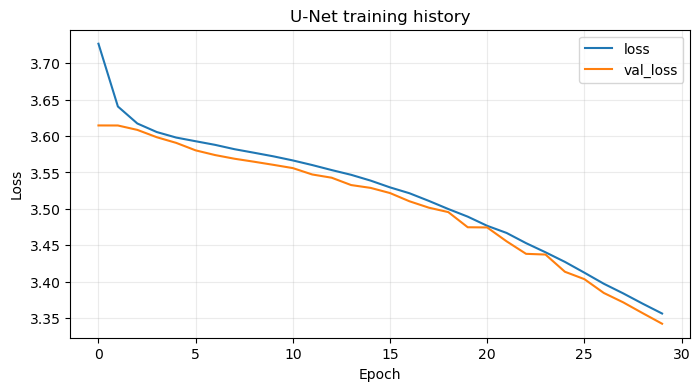

,dice_coef_tf,loss,val_dice_coef_tf,val_loss,learning_rate
25,0.017010,3.385051,0.016336,3.357934,0.00003
26,0.018106,3.366600,0.017065,3.331558,0.00003
27,0.017775,3.352039,0.017473,3.322073,0.00003
28,0.018805,3.338540,0.018056,3.299951,0.00003
29,0.018963,3.321636,0.018975,3.291656,0.00003


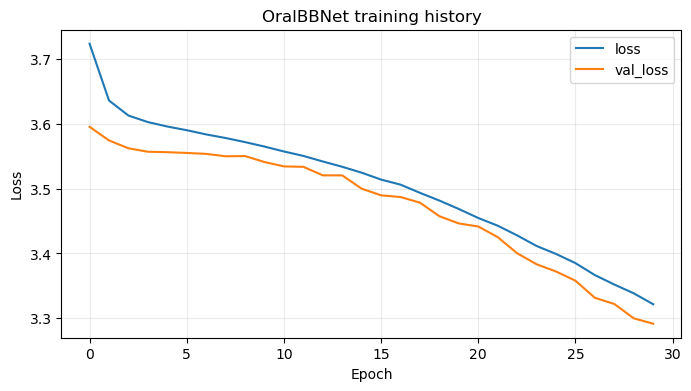

In [16]:
def plot_training_history(history, title: str) -> None:
    """绘制训练集和验证集 loss 曲线。"""
    if history is None:
        print(f"Warning: {title} history is not available")
        return
    history_df = pd.DataFrame(history)
    display(history_df.tail())
    ax = history_df[[column for column in history_df.columns if "loss" in column]].plot(figsize=(8, 4), title=title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    plt.grid(alpha=0.25)
    plt.show()


plot_training_history(unet_history, "U-Net training history")
plot_training_history(oralbbnet_history, "OralBBNet training history")


## 定性结果

最后展示测试集样本的定性对比。对于深度学习模型，同时展示概率热图和阈值化后的二值 mask，便于观察模型是否存在过度预测或漏检。输出图像保存为 `results/qualitative_examples.png`。


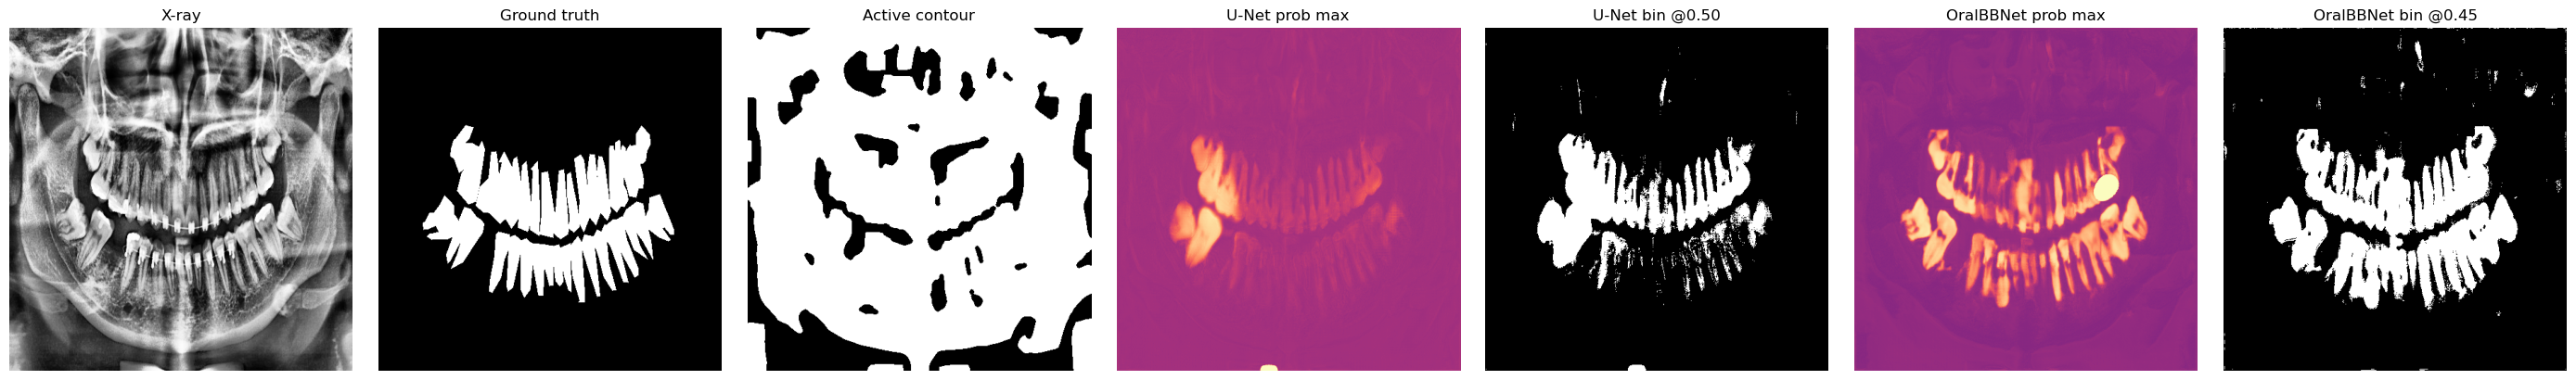

Saved qualitative figure to /oral_llm/xiweidai/dentalagent2/Instance_seg_teeth/results/qualitative_examples.png


In [17]:
def plot_qualitative_results(
    index: int = 0,
    save_path: Path = RESULTS_DIR / "qualitative_examples.png",
) -> None:
    """绘制测试样本的定性对比结果。"""
    image = test_x[index]
    gt = test_y[index]
    active = active_predictions[index]
    unet_prob = prediction_union(unet_pred[index])
    oral_prob = prediction_union(oralbbnet_pred[index])
    unet_bin = binarize_prediction(unet_pred[index], threshold=unet_threshold)
    oral_bin = binarize_prediction(oralbbnet_pred[index], threshold=oralbbnet_threshold)

    panels = [
        ("X-ray", image.squeeze(), "gray", None),
        ("Ground truth", mask_union(gt), "gray", None),
        ("Active contour", active, "gray", None),
        (f"U-Net prob max", unet_prob, "magma", (0.0, 1.0)),
        (f"U-Net bin @{unet_threshold:.2f}", unet_bin, "gray", None),
        (f"OralBBNet prob max", oral_prob, "magma", (0.0, 1.0)),
        (f"OralBBNet bin @{oralbbnet_threshold:.2f}", oral_bin, "gray", None),
    ]

    fig, axes = plt.subplots(1, len(panels), figsize=(4 * len(panels), 4))
    for axis, (title, data, cmap, limits) in zip(axes, panels):
        kwargs = {"cmap": cmap}
        if limits is not None:
            kwargs.update({"vmin": limits[0], "vmax": limits[1]})
        axis.imshow(data, **kwargs)
        axis.set_title(title)
        axis.axis("off")
    plt.tight_layout()
    fig.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved qualitative figure to {save_path}")


plot_qualitative_results(0)


## 实验总结

本实验通过三种方法比较牙齿实例分割效果。Active Contour 不依赖标注训练，但难以稳定区分牙齿与背景；U-Net 能从监督标签中学习牙齿区域；OralBBNet 进一步引入边界框先验，用牙位空间信息辅助分割。最终比较重点关注 Dice、IoU、分组 Dice 以及可视化结果。
